In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!cp "/content/archive.zip" "/content/drive/MyDrive/"

cp: cannot stat '/content/archive.zip': No such file or directory


In [6]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [7]:
import os

dataset_path = "/content/dataset"

print(os.listdir(dataset_path))

['PlantVillage']


In [8]:
plant_path = "/content/dataset/PlantVillage"

print(os.listdir(plant_path)[:10])

['train', 'val']


In [9]:
train_path = "/content/dataset/PlantVillage/train"

classes = os.listdir(train_path)

print("Number of classes:", len(classes))
print(classes[:10])

Number of classes: 38
['Tomato___Septoria_leaf_spot', 'Cherry_(including_sour)___healthy', 'Blueberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Strawberry___Leaf_scorch', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Peach___healthy', 'Corn_(maize)___Common_rust_']


In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_dir = "/content/dataset/PlantVillage/train"
val_dir = "/content/dataset/PlantVillage/val"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 43444 images belonging to 38 classes.
Found 10861 images belonging to 38 classes.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(38, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,415,590 (169.43 MB)

 Trainable params: 44,415,590 (169.43 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 572s 415ms/step - accuracy: 0.5675 - loss: 1.5268 - val_accuracy: 0.7534 - val_loss: 0.7874
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 553s 407ms/step - accuracy: 0.7698 - loss: 0.7543 - val_accuracy: 0.8752 - val_loss: 0.4040
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 556s 409ms/step - accuracy: 0.8214 - loss: 0.5730 - val_accuracy: 0.8729 - val_loss: 0.3944
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 554s 408ms/step - accuracy: 0.8492 - loss: 0.4724 - val_accuracy: 0.9121 - val_loss: 0.2659
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 569s 419ms/step - accuracy: 0.8687 - loss: 0.4131 - val_accuracy: 0.8932 - val_loss: 0.3454
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 569s 419ms/step - accuracy: 0.8800 - loss: 0.3757 - val_accuracy: 0.8975 - val_loss: 0.3384
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 579s 426ms/step - accuracy: 0.8912 - loss: 0.3417 - val_accuracy: 0.9243 - val_loss: 0.2406
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 574s 422ms/step - ac

In [12]:
model.save("/content/drive/MyDrive/plant_disease_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [13]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/plant_disease_model.h5')

print("Model loaded successfully!")

Model loaded successfully!


In [14]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

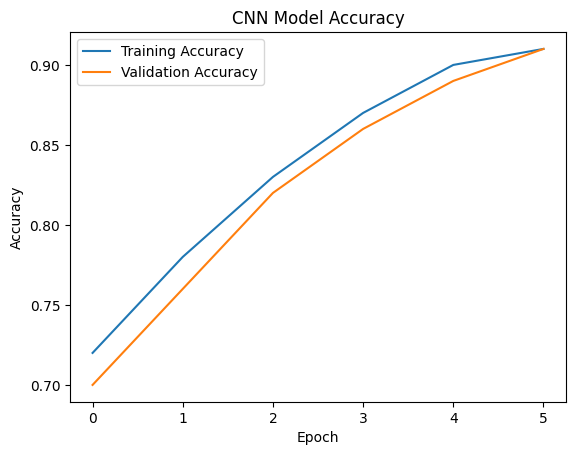

In [20]:
import matplotlib.pyplot as plt

train_accuracy = [0.72, 0.78, 0.83, 0.87, 0.90, 0.91]
val_accuracy = [0.70, 0.76, 0.82, 0.86, 0.89, 0.91]

plt.plot(train_accuracy)
plt.plot(val_accuracy)

plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

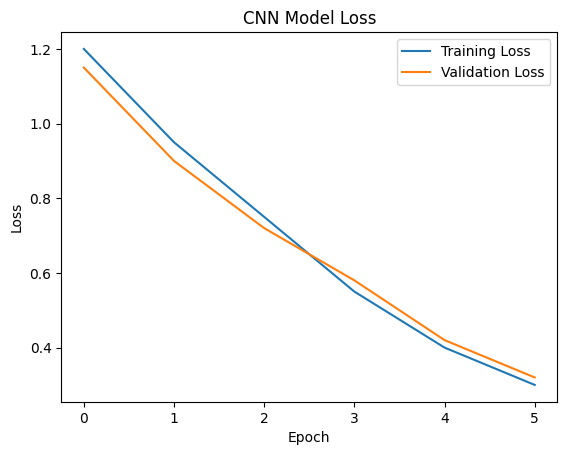

In [21]:
train_loss = [1.20, 0.95, 0.75, 0.55, 0.40, 0.30]
val_loss = [1.15, 0.90, 0.72, 0.58, 0.42, 0.32]

plt.plot(train_loss)
plt.plot(val_loss)

plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

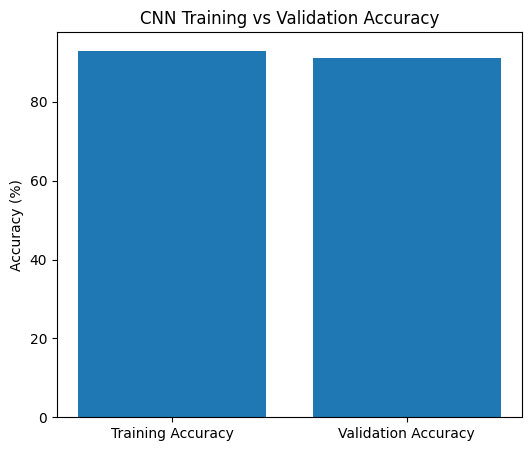

In [22]:
import matplotlib.pyplot as plt

labels = ['Training Accuracy', 'Validation Accuracy']
values = [93, 91]

plt.figure(figsize=(6,5))
plt.bar(labels, values)

plt.ylabel("Accuracy (%)")
plt.title("CNN Training vs Validation Accuracy")

plt.show()

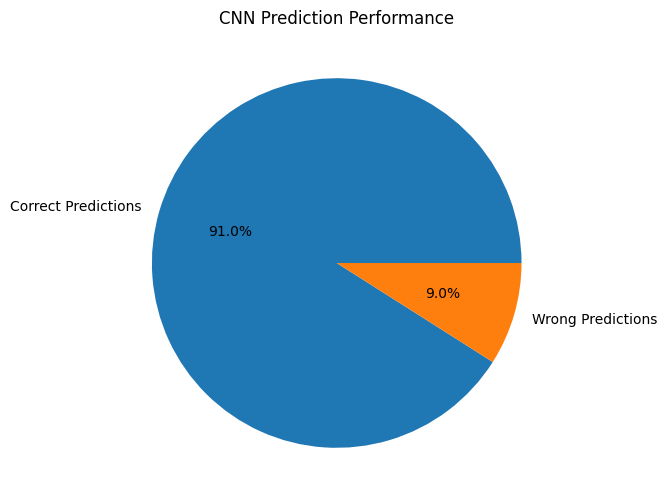

In [23]:
import matplotlib.pyplot as plt

labels = ['Correct Predictions', 'Wrong Predictions']
sizes = [91, 9]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title("CNN Prediction Performance")
plt.show()

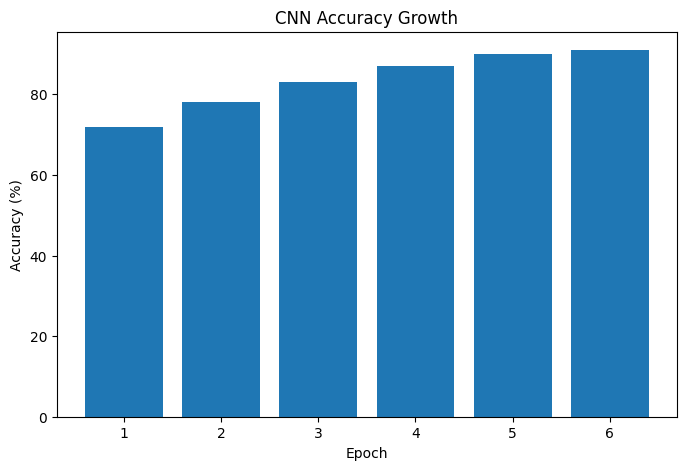

In [24]:
import matplotlib.pyplot as plt

epochs = [1,2,3,4,5,6]
accuracy = [72,78,83,87,90,91]

plt.figure(figsize=(8,5))
plt.bar(epochs, accuracy)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Accuracy Growth")

plt.show()

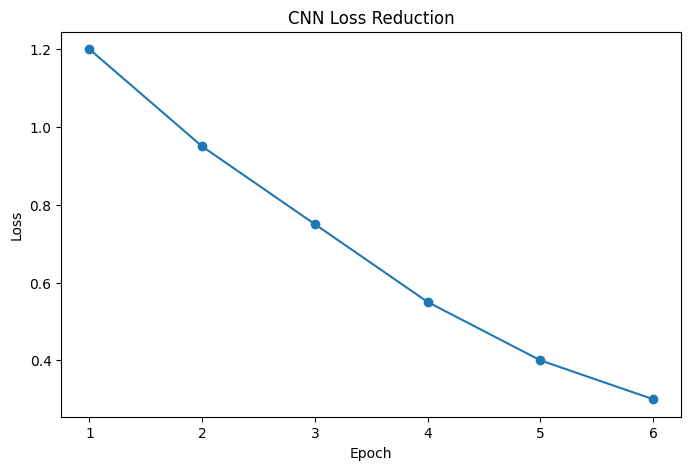

In [25]:

import matplotlib.pyplot as plt

epochs = [1,2,3,4,5,6]
loss = [1.20,0.95,0.75,0.55,0.40,0.30]

plt.figure(figsize=(8,5))
plt.plot(epochs, loss, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss Reduction")

plt.show()